In [176]:
import mysql.connector
from mysql.connector import Error
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
from datetime import datetime, date, time, timedelta
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Useful functions
def flip(series: pd.Series) -> pd.Series:
    flipped = -series
    flipped[series == 0] = 0.0
    return flipped

# RAG

In [177]:
try:
    connection = mysql.connector.connect(
        host="localhost",
        user="root",
        password="venomio",
        database="vsp"
    )
    
    if connection.is_connected():       
        cursor = connection.cursor()

        cursor.execute(
            """
            SELECT 
                mg.id,
                mg.home_elevation_dif,
                mg.away_elevation_dif,
                mg.away_travel,
                mg.date,
                SUM(md.teamA_fr_rag) AS teamA_fr_rag,
                SUM(md.teamB_fr_rag) AS teamB_fr_rag,
                SUM(md.minutes_played) AS minutes_played,
                md.time_segment,
                md.match_state,
                md.player_dif,
                SUM(md.teamA_xg) AS teamA_xg,
                SUM(md.teamB_xg) AS teamB_xg
            FROM match_general mg
            JOIN match_detailed md
                ON mg.id = md.match_id
            WHERE md.minutes_strength >= 0.7
            AND md.minutes_played >= 5
            AND DATE(mg.date) < "2024-05-13"
            AND teamA_fr_rag IS NOT NULL
            AND teamB_fr_rag IS NOT NULL
            GROUP BY md.match_id, md.match_state, md.player_dif, md.time_segment
            """
            )
        column_names = [desc[0] for desc in cursor.description] 
        context_df = pd.DataFrame(cursor.fetchall(), columns=column_names)
            
except Error as e:
    print(f"Error while connecting to MySQL: {e}")
    
finally:
    if connection.is_connected():
        cursor.close()
        connection.close()

context_df = context_df.replace([np.inf, -np.inf], np.nan).dropna()
context_df['home_elevation_dif']  = pd.to_numeric(context_df['home_elevation_dif'],  errors='raise').astype(int)
context_df['away_elevation_dif']  = pd.to_numeric(context_df['away_elevation_dif'],  errors='raise').astype(int)
context_df['away_travel']  = pd.to_numeric(context_df['away_travel'],  errors='raise').astype(int)
context_df['date'] = pd.to_datetime(context_df['date'])
context_df['teamA_fr_rag']  = pd.to_numeric(context_df['teamA_fr_rag'],  errors='raise').astype(float)
context_df['teamB_fr_rag']  = pd.to_numeric(context_df['teamB_fr_rag'],  errors='raise').astype(float)
context_df['minutes_played']  = pd.to_numeric(context_df['minutes_played'],  errors='raise').astype(int)
context_df['time_segment'] = pd.to_numeric(context_df['time_segment'], errors='raise').astype(int)
context_df['match_state'] = pd.to_numeric(context_df['match_state'], errors='raise').astype(float)
context_df['player_dif']  = pd.to_numeric(context_df['player_dif'],  errors='raise').astype(float)
context_df['teamA_xg']  = pd.to_numeric(context_df['teamA_xg'],  errors='raise').astype(float)
context_df['teamB_xg']  = pd.to_numeric(context_df['teamB_xg'],  errors='raise').astype(float)
context_df.head()

,id,home_elevation_dif,away_elevation_dif,away_travel,date,teamA_fr_rag,teamB_fr_rag,minutes_played,time_segment,match_state,player_dif,teamA_xg,teamB_xg
0,20668,2,12,193,2024-01-01 20:00:00,0.604473,0.379268,15,1,0.0,0.0,0.80,0.08
1,20668,2,12,193,2024-01-01 20:00:00,0.604473,0.379268,15,2,0.0,0.0,1.38,0.00
2,20668,2,12,193,2024-01-01 20:00:00,0.805964,0.505690,20,3,0.0,0.0,0.60,0.00
3,20668,2,12,193,2024-01-01 20:00:00,0.201491,0.126423,5,4,0.5,0.0,0.52,0.25
4,20668,2,12,193,2024-01-01 20:00:00,0.232852,0.146575,6,4,0.0,0.0,0.00,0.00


In [178]:
home_df = pd.DataFrame({
    'xg'                 : context_df['teamA_xg'],
    'fr_rag'            : context_df['teamA_fr_rag'],
    'minutes_played'     : context_df['minutes_played'],
    'time_segment'       : context_df['time_segment'],
    'is_home'            : 1,
    'elevation_dif'      : context_df['home_elevation_dif'],
    'travel'             : -context_df['away_travel'],
    'match_state'        : context_df['match_state'],
    'player_dif'         : context_df['player_dif']
})

away_df = pd.DataFrame({
    'xg'                 : context_df['teamB_xg'],
    'fr_rag'            : context_df['teamB_fr_rag'],
    'minutes_played'     : context_df['minutes_played'],
    'time_segment'       : context_df['time_segment'],
    'is_home'            : 0,
    'elevation_dif'      : context_df['away_elevation_dif'],
    'travel'             : context_df['away_travel'],
    'match_state'        : flip(context_df['match_state']),
    'player_dif'         : flip(context_df['player_dif'])
})

df = pd.concat([home_df, away_df], ignore_index=True)
df

,xg,fr_rag,minutes_played,time_segment,is_home,elevation_dif,travel,match_state,player_dif
0,0.80,0.604473,15,1,1,2,-193,0.0,0.0
1,1.38,0.604473,15,2,1,2,-193,0.0,0.0
2,0.60,0.805964,20,3,1,2,-193,0.0,0.0
3,0.52,0.201491,5,4,1,2,-193,0.5,0.0
4,0.00,0.232852,6,4,1,2,-193,0.0,0.0
...,...,...,...,...,...,...,...,...,...
16987,0.04,0.277796,15,2,0,-21,90,0.0,0.0
16988,0.31,0.203717,11,3,0,-21,90,0.5,0.0
16989,0.00,0.191753,10,4,0,-21,90,1.5,0.0
16990,0.00,0.270333,13,5,0,-21,90,1.5,0.0


In [179]:
summary = df.describe(include="all").T
summary["mode"] = df.mode().values[0]
summary["n_unique"] = df.nunique()
summary["null_count"] = df.isnull().sum()
summary["skewness"] = df.skew(numeric_only=True)
summary["type"] = df.dtypes
summary

,count,mean,std,min,25%,50%,75%,max,mode,n_unique,null_count,skewness,type
xg,16992.0,0.161895,0.238027,0.000000,0.000000,0.070000,0.210000,2.830000,0.00000,502,0,2.476110,float64
fr_rag,16992.0,0.251619,0.114221,0.026295,0.164982,0.239223,0.322272,1.450618,0.13191,14572,0,0.847632,float64
minutes_played,16992.0,12.194562,3.998667,5.000000,9.000000,13.000000,15.000000,41.000000,15.00000,27,0,-0.076221,int32
time_segment,16992.0,3.481638,1.706811,1.000000,2.000000,3.000000,5.000000,6.000000,3.00000,6,0,0.027378,int32
is_home,16992.0,0.500000,0.500015,0.000000,0.000000,0.500000,1.000000,1.000000,0.00000,2,0,0.000000,int64
elevation_dif,16992.0,-0.459334,66.595712,-119.000000,-32.000000,-9.000000,12.000000,236.000000,-21.00000,108,0,1.335418,int32
travel,16992.0,0.000000,421.933505,-2260.000000,-226.000000,0.000000,226.000000,2260.000000,-84.00000,1139,0,0.000000,int32
match_state,16992.0,0.000000,0.672356,-1.500000,-0.500000,0.000000,0.500000,1.500000,0.00000,5,0,0.000000,float64
player_dif,16992.0,0.000000,0.124295,-1.500000,0.000000,0.000000,0.000000,1.500000,0.00000,5,0,0.000000,float64


In [180]:
concat_df = pd.concat([home_df, away_df], ignore_index=True)
clean_df = concat_df.copy()

clean_df['xg90'] = (clean_df['xg'] / clean_df['minutes_played']) * 90
clean_df['rag90'] = (clean_df['fr_rag'] / clean_df['minutes_played']) * 90

cat_cols  = ['match_state', 'player_dif', 'time_segment']
bool_cols = ['is_home']
num_cols  = ['elevation_dif', 'travel']

missing_cols  = [c for c in ['xg90', 'rag90'] if c not in clean_df.columns]
if missing_cols:
    raise ValueError(f'Missing expected columns: {missing_cols}')

sample_weights = np.sqrt(clean_df['minutes_played'] / clean_df['minutes_played'].max())

for c in cat_cols:
    clean_df[c] = clean_df[c].astype(str).str.lower()

clean_df[bool_cols] = clean_df[bool_cols].astype(int)

X_cat = pd.get_dummies(clean_df[cat_cols], prefix=cat_cols)
X = pd.concat([clean_df[num_cols], clean_df[bool_cols], X_cat], axis=1)

y = clean_df['xg90']
base_margin = np.log(clean_df['rag90'].clip(lower=0.01))

dtrain = xgb.DMatrix(X, label=y, base_margin=base_margin, weight=sample_weights)

params = dict(objective='count:poisson',
                tree_method='hist',
                max_depth=15,
                eta=0.05,
                subsample=1.0,
                colsample_bytree=1.0,
                min_child_weight=5,
                gamma=1,
                reg_alpha=0.5,
                reg_lambda=1.0,
                max_delta_step=1)

cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=1000,
    nfold=5,
    early_stopping_rounds=50,
    metrics='poisson-nloglik',
    verbose_eval=False
)

optimal_rounds = len(cv_results)
booster = xgb.train(params, dtrain, num_boost_round=optimal_rounds)

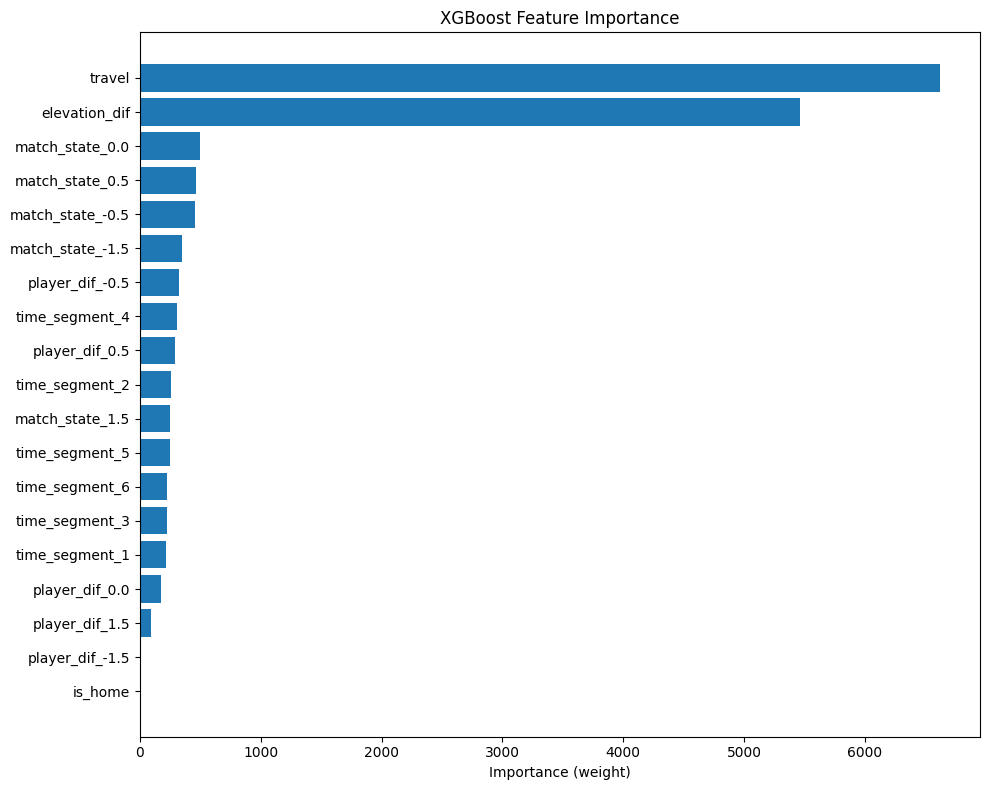

Feature Importance Scores:
             feature  importance
1             travel      6622.0
0      elevation_dif      5461.0
5    match_state_0.0       500.0
6    match_state_0.5       466.0
3   match_state_-0.5       456.0
4   match_state_-1.5       349.0
8    player_dif_-0.5       323.0
16    time_segment_4       308.0
11    player_dif_0.5       291.0
14    time_segment_2       261.0
7    match_state_1.5       252.0
17    time_segment_5       249.0
18    time_segment_6       227.0
15    time_segment_3       223.0
13    time_segment_1       219.0
10    player_dif_0.0       179.0
12    player_dif_1.5        95.0
9    player_dif_-1.5        10.0
2            is_home         9.0


In [181]:
# Feature Importance
importance_scores = booster.get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'feature': list(importance_scores.keys()),
    'importance': list(importance_scores.values())
}).sort_values('importance', ascending=True)

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance (weight)')
plt.tight_layout()
plt.show()

# Print importance scores
print("Feature Importance Scores:")
print(importance_df.sort_values('importance', ascending=False))

C:\Users\markg\AppData\Local\Temp\ipykernel_21556\3232184934.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


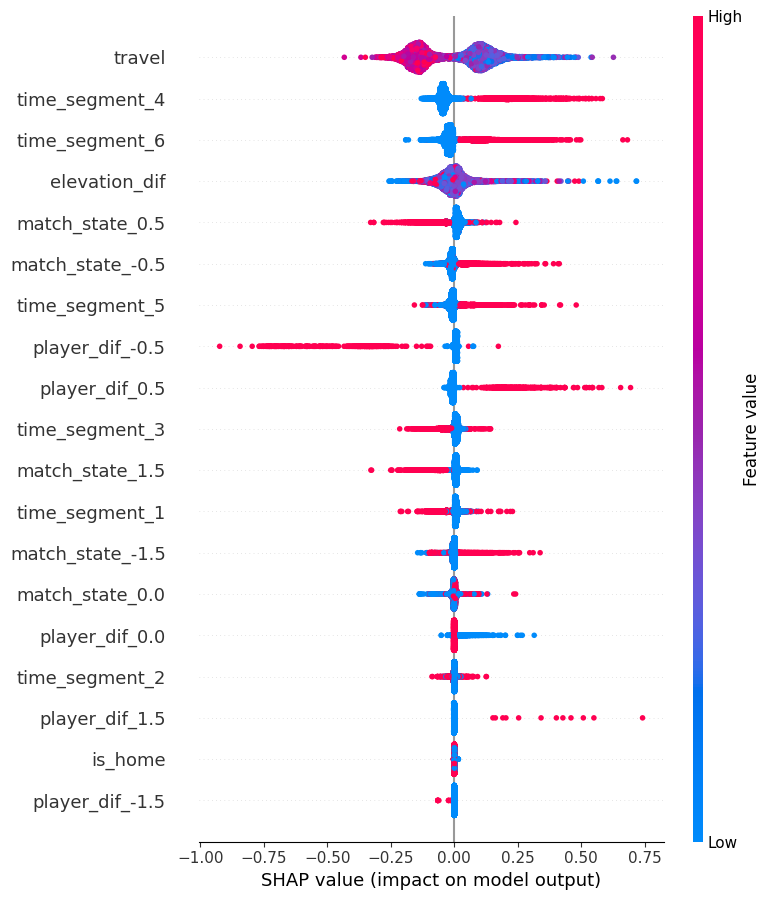

In [182]:
import shap

explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values, X)

# Get mean absolute SHAP values
shap_importance = np.abs(shap_values).mean(0)

In [183]:
# Generate predictions
predictions = booster.predict(dtrain)

# Your existing code for model predictions
clean_df['predicted_xg'] = predictions

# Calculate metrics for your model
mae_model = mean_absolute_error(clean_df['xg90'], predictions)
rmse_model = np.sqrt(mean_squared_error(clean_df['xg90'], predictions))

# Calculate metrics using rag90 as the prediction
mae_rag90 = mean_absolute_error(clean_df['xg90'], clean_df['rag90'])
rmse_rag90 = np.sqrt(mean_squared_error(clean_df['xg90'], clean_df['rag90']))

print(f"\nModel Performance vs rag90 Baseline:")
print(f"MAE - Model: {mae_model:.4f}, rag90: {mae_rag90:.4f}")
print(f"RMSE - Model: {rmse_model:.4f}, rag90: {rmse_rag90:.4f}")

# Calculate improvement percentages
mae_improvement = ((mae_rag90 - mae_model) / mae_rag90) * 100
rmse_improvement = ((rmse_rag90 - rmse_model) / rmse_rag90) * 100

print(f"\nImprovement over rag90:")
print(f"MAE improvement: {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

# You can also compare side-by-side in a dataframe
comparison = pd.DataFrame({
    'actual_xg90': clean_df['xg90'],
    'predicted_xg90': predictions,
    'rag90_prediction': clean_df['rag90']
})

print("\nComparison sample:")
print(comparison.tail(20))

# What this improvement means in practical terms
avg_xg90 = clean_df['xg90'].mean()
print(f"Average xg90: {avg_xg90:.2f}")
print(f"Model error rate: {(mae_model/avg_xg90)*100:.1f}%")
print(f"rag90 error rate: {(mae_rag90/avg_xg90)*100:.1f}%")


Model Performance vs rag90 Baseline:
MAE - Model: 1.2287, rag90: 1.6308
RMSE - Model: 1.9767, rag90: 2.2502

Improvement over rag90:
MAE improvement: 24.66%
RMSE improvement: 12.15%

Comparison sample:
       actual_xg90  predicted_xg90  rag90_prediction
16972     0.000000        1.335155          2.498378
16973     0.000000        1.336463          2.498378
16974     0.000000        1.258699          2.498378
16975     2.925000        1.595531          2.525394
16976     0.375000        1.180082          2.223069
16977     0.000000        1.085741          2.204819
16978     3.900000        1.316991          2.388895
16979     0.000000        1.276646          2.388895
16980     2.007692        1.342016          2.388895
16981     0.000000        1.200915          2.388895
16982     0.000000        1.195145          2.388895
16983     0.385714        1.574544          2.416655
16984     0.000000        1.371973          2.416655
16985     0.128571        1.763446          2.627932
16

In [196]:
def predict_shots_simple(model, features_dict, raxg90):
    """
    Corrected predictor that handles feature alignment properly
    """
    # Create base margin (same as training)
    base_margin = np.log(max(raxg90, 0.1))
    
    # Convert to DataFrame
    feature_df = pd.DataFrame([features_dict])
    
    # Apply same preprocessing as training
    cat_cols = ['match_state', 'player_dif', 'time_segment']
    for col in cat_cols:
        feature_df[col] = feature_df[col].astype(str).str.lower()
    
    bool_cols = ['is_home']
    for col in bool_cols:
        feature_df[col] = feature_df[col].astype(int)
    
    # One-hot encode categoricals
    X_cat = pd.get_dummies(feature_df[cat_cols], prefix=cat_cols)
    X_num_bool = feature_df[['elevation_dif', 'travel'] + bool_cols]
    X_input = pd.concat([X_num_bool, X_cat], axis=1)
    
    # CRITICAL: Align with training columns exactly
    # Get the expected columns from the training data
    training_columns = X.columns
    
    # Reindex to match training columns, fill missing with 0
    X_input = X_input.reindex(columns=training_columns, fill_value=0)
    
    # Ensure column order matches exactly
    X_input = X_input[training_columns]
    
    # Predict
    dinput = xgb.DMatrix(X_input, base_margin=[base_margin])
    return model.predict(dinput)[0]

# Test with data that matches your training format
sample_features = {
    'match_state': '0.0',           
    'player_dif': '0.0',   
    'time_segment': '6',   
    'is_home': 1,
    'elevation_dif': 25,
    'travel': -100,
}

prediction = predict_shots_simple(booster, sample_features, raxg90=1)
print(f"Predicted shots per 90: {prediction:.2f}")

Predicted shots per 90: 0.86


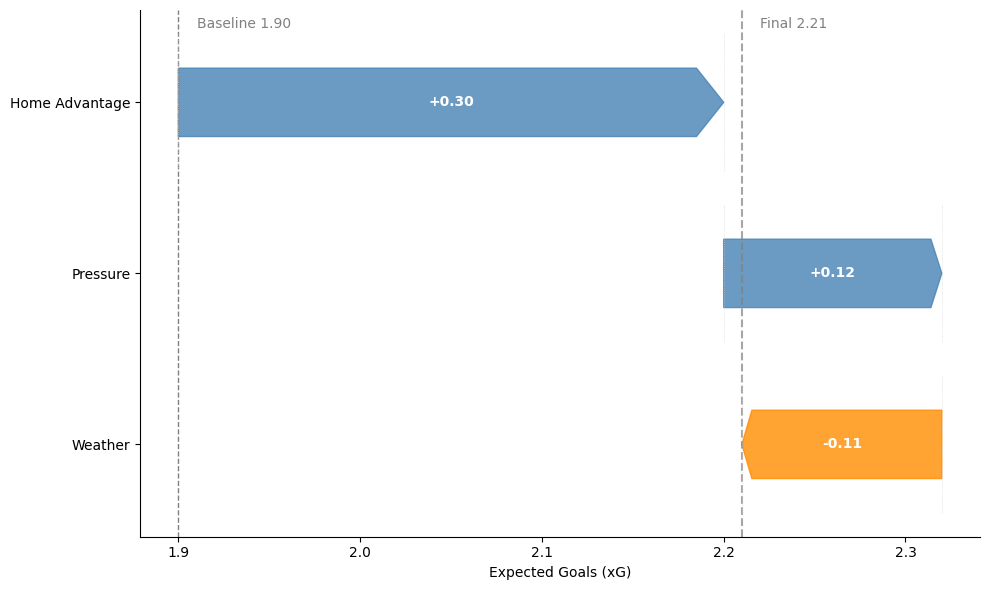

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def shap_waterfall(baseline, contributions, final_value, use_arrows=True):
    """
    Create a waterfall chart similar to SHAP's explanation plots.
    
    Parameters:
    - baseline: float, starting value (e.g., league average)
    - contributions: list of (label, value) tuples, where value is the additive contribution
    - final_value: float, the sum of baseline and all contributions
    - title: str, chart title
    """
    # Prepare data
    labels = [c[0] for c in contributions]
    values = [c[1] for c in contributions]
    
    # Cumulative positions: start at baseline, then add each contribution
    cum = np.cumsum([baseline] + values)
    start_positions = cum[:-1]  # where each bar starts
    end_positions = cum[1:]     # where each bar ends
    
    # Colors: positive = red, negative = blue
    colors = ['steelblue' if v > 0 else 'darkorange' for v in values]
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot bars horizontally
    y_pos = np.arange(len(contributions))
    for i, (start, end, color) in enumerate(zip(start_positions, end_positions, colors)):
        width = end - start
        if use_arrows:
            # Use an arrow to show direction
            ax.arrow(start, y_pos[i], width, 0,
                     head_width=0.4, head_length=0.05 * abs(width),
                     fc=color, ec=color, width=0.4, alpha=0.8,
                     length_includes_head=True)
        else:
            # Simple rectangle bar
            ax.barh(y_pos[i], width, left=start, color=color)

        # Add value label inside/next to bar
        x_label = start + width / 2
        ax.text(x_label, y_pos[i], f'{width:+.2f}',
                ha='center', va='center', color='white', fontweight='bold')
    
    # Add baseline as a vertical line (or a marker)
    ax.axvline(x=baseline, color='gray', linestyle='--', linewidth=1, label=f'Baseline: {baseline:.2f}')
    
    # Add final value marker
    ax.axvline(x=final_value, color='gray', alpha=0.7, linestyle='--', linewidth=1.5, label=f'Final: {final_value:.2f}')
    
    # Set y-axis labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()  # so first contribution is on top

    # Annotate baseline and final
    ax.text(baseline+0.01, -0.5, f'Baseline {baseline:.2f}', ha='left', va='top', color='gray')
    ax.text(final_value+0.01, -0.5, f'Final {final_value:.2f}', ha='left', va='top', color='gray')
    
    # Add a connecting line between cumulative points (like SHAP's "stems")
    for i in range(len(start_positions)):
        ax.plot([start_positions[i], start_positions[i]], [i-0.4, i+0.4], color='lightgray', linestyle=':', linewidth=0.5)
    for i in range(len(end_positions)):
        ax.plot([end_positions[i], end_positions[i]], [i-0.4, i+0.4], color='lightgray', linestyle=':', linewidth=0.5)
    
    # Labels and title
    ax.set_xlabel('Expected Goals (xG)')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Stage 2: Contextual adjustment
    baseline = 1.9          
    contributions = [
        ("Home Advantage", 0.30),
        ("Pressure", 0.12),
        ("Weather", -0.11)
    ]
    final_xg = 2.21            
    
    # Verify sum
    assert abs(baseline + sum(c[1] for c in contributions) - final_xg) < 1e-6, "Contributions don't sum to final value"
    
    shap_waterfall(baseline, contributions, final_xg)